In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mtsamples/mtsamples.csv
/kaggle/input/mtsamples-predictions/mtsamples_predictions/qwen_predictions.csv
/kaggle/input/mtsamples-predictions/mtsamples_predictions/biomistral_predictions.csv
/kaggle/input/mtsamples-predictions/mtsamples_predictions/mistral_predictions.csv
/kaggle/input/mtsamples-predictions/mtsamples_predictions/gemma_predictions.csv


In [22]:
# CELL 1: Setup and Imports
# ====================================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✓ Imports complete")

✓ Imports complete


In [23]:
# CELL 2: Load ALL MTSamples Data (Including Metadata)
# ====================================================================

# Paths
PRED_DIR = "/kaggle/input/mtsamples-predictions/mtsamples_predictions"
DATA_PATH = "/kaggle/input/mtsamples/mtsamples.csv"
OUTPUT_DIR = "/kaggle/working"

# Load full MTSamples with ALL columns
full_mtsamples = pd.read_csv(DATA_PATH)

print(f"✓ Loaded MTSamples: {len(full_mtsamples)} notes")
print(f"  Columns: {full_mtsamples.columns.tolist()}")

# Create note_id for merging
full_mtsamples['note_id'] = full_mtsamples.index

# Keep only needed columns
notes_df = full_mtsamples[['note_id', 'transcription', 'keywords', 'medical_specialty', 'description']].copy()

print(f"\n✓ Created notes dataframe with metadata")

✓ Loaded MTSamples: 4999 notes
  Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

✓ Created notes dataframe with metadata


In [24]:
# # CELL 3: Extract Diagnosis Terms from Dataset (DATA-DRIVEN)
# # ====================================================================

# print("="*70)
# print("EXTRACTING DIAGNOSIS TERMS FROM MTSAMPLES KEYWORDS")
# print("="*70)

# # Extract all keywords from the dataset
# all_keywords = []

# for keywords_str in full_mtsamples['keywords'].dropna():
#     # Split by comma and clean
#     keywords = [k.strip().lower() for k in str(keywords_str).split(',')]
#     all_keywords.extend(keywords)

# # Get unique keywords and their frequencies
# keyword_counts = Counter(all_keywords)

# # Filter out non-medical terms (very frequent or very rare)
# # Keep terms that appear 2-100 times (likely diagnosis terms)
# diagnosis_candidates = {
#     kw for kw, count in keyword_counts.items()
#     if 2 <= count <= 100 and len(kw) > 3  # Ignore very short terms
# }

# print(f"\n✓ Extracted {len(diagnosis_candidates)} potential diagnosis terms from keywords")

# # Also extract from medical_specialty column
# specialties = full_mtsamples['medical_specialty'].dropna().unique()
# print(f"✓ Found {len(specialties)} medical specialties")

# # Common diagnosis suffixes (medical terminology patterns)
# DIAGNOSIS_SUFFIXES = [
#     'itis',      # inflammation (bronchitis, arthritis)
#     'osis',      # condition (fibrosis, stenosis)
#     'pathy',     # disease (neuropathy, cardiomyopathy)
#     'emia',      # blood condition (anemia, leukemia)
#     'oma',       # tumor (carcinoma, lymphoma)
#     'algia',     # pain (neuralgia)
#     'megaly',    # enlargement (cardiomegaly)
#     'trophy',    # growth (hypertrophy)
#     'plasty',    # surgical repair
#     'ectomy',    # surgical removal
# ]

# # Extract diagnosis terms based on medical suffixes
# suffix_diagnoses = {
#     kw for kw in diagnosis_candidates
#     if any(kw.endswith(suffix) for suffix in DIAGNOSIS_SUFFIXES)
# }

# print(f"✓ Identified {len(suffix_diagnoses)} terms with medical suffixes")

# # Combine all diagnosis terms
# DIAGNOSIS_TERMS = diagnosis_candidates

# print(f"\n✓ Final diagnosis term list: {len(DIAGNOSIS_TERMS)} terms")
# print(f"\nSample diagnosis terms: {list(sorted(DIAGNOSIS_TERMS))[:20]}")

# # Save for reference
# diagnosis_df = pd.DataFrame({
#     'term': list(DIAGNOSIS_TERMS),
#     'type': 'diagnosis'
# })
# diagnosis_df.to_csv(f'{OUTPUT_DIR}/extracted_diagnosis_terms.csv', index=False)
# print(f"\n✓ Saved: extracted_diagnosis_terms.csv")

In [25]:
# ============================================================
# DIAGNOSIS DETECTION (REVIEWER-SAFE)
# ============================================================

# 1️⃣ Medical diagnosis suffixes (high precision)
DIAGNOSIS_SUFFIXES = [
    "itis",      # inflammation
    "osis",      # disease/condition
    "oma",       # tumors
    "emia",      # blood conditions
    "pathy",     # disease
    "megaly",    # enlargement
    "trophy",    # growth disorder
    "algia",     # pain syndrome
    "sclerosis",
    "stenosis"
]

# 2️⃣ Small curated diagnosis list (high-risk canonical diagnoses)
CURATED_DIAGNOSES = {
    # Respiratory
    "asthma", "pneumonia", "copd", "bronchitis", "sinusitis", "tuberculosis", "emphysema",
    
    # Cardiovascular
    "hypertension", "hypotension", "heart failure", 
    "myocardial infarction", "arrhythmia", "cardiomyopathy",
    
    # Endocrine
    "diabetes", "hypothyroidism", "hyperthyroidism",
    
    # GI
    "gerd", "hepatitis", "cirrhosis", "colitis",
    
    # Neuro
    "stroke", "seizure", "epilepsy", "parkinsons", "alzheimers",
    
    # Infection / oncology
    "sepsis", "cancer", "tumor", "carcinoma", "lymphoma", "leukemia", "neoplasm",
    
    # Generic clinical labels
    "disease", "disorder", "syndrome"
}

BORDERLINE_CONDITIONS = {
    "fracture", "anemia", "infection", "abscess",
    "tachycardia", "bradycardia", "migraine",
    "depression", "anxiety", "ptsd", "bipolar",
    "arthritis", "osteoporosis"
}

def is_diagnosis_term(text: str) -> bool:
    """
    Conservative diagnosis detection.
    Returns True only for high-confidence diagnosis expressions.
    """
    if not isinstance(text, str):
        return False
    
    t = text.lower().strip()
    
    # Exact curated diagnosis match
    if t in CURATED_DIAGNOSES:
        return True
    
    # Multi-word diagnosis phrases
    for diag in CURATED_DIAGNOSES:
        if diag in t and len(t.split()) <= 4:
            return True
    
    # Suffix-based detection (high precision)
    for suffix in DIAGNOSIS_SUFFIXES:
        if t.endswith(suffix):
            return True
    
    return False

In [26]:
# CELL 4: Extract Medication Patterns from Dataset (DATA-DRIVEN)
# ====================================================================

print("\n" + "="*70)
print("EXTRACTING MEDICATION PATTERNS FROM TRANSCRIPTIONS")
print("="*70)

# Common medication name patterns (brand names often capitalized)
medication_patterns_found = set()

# Sample 1000 random notes to extract medication patterns
sample_notes = full_mtsamples['transcription'].dropna().sample(min(1000, len(full_mtsamples)), random_state=42)

for note in sample_notes:
    note_str = str(note)
    
    # Extract capitalized words (often brand names)
    # Pattern: word ending in common med suffixes or units
    words = re.findall(r'\b[A-Z][a-z]+(?:in|ol|ide|azole|mycin|cillin|pril|sartan|statin)\b', note_str)
    medication_patterns_found.update(w.lower() for w in words)
    
    # Extract dosage patterns
    dosage_matches = re.findall(r'\b(\d+(?:\.\d+)?)\s*(mg|ml|mcg|units?|tablets?|capsules?)\b', note_str, re.IGNORECASE)
    medication_patterns_found.update(match[1].lower() for match in dosage_matches)

print(f"✓ Extracted {len(medication_patterns_found)} medication/dosage patterns")

# Common units and forms
MEDICATION_PATTERNS = list(medication_patterns_found) + [
    'mg', 'ml', 'mcg', 'grams', 'units', 'iu',
    'tablet', 'tablets', 'capsule', 'capsules', 'pill', 'pills',
    'dose', 'doses', 'dosage', 'bid', 'tid', 'qid', 'prn',
    'daily', 'twice daily', 'three times',
]

MEDICATION_PATTERNS = list(set(MEDICATION_PATTERNS))  # Remove duplicates

print(f"✓ Final medication pattern list: {len(MEDICATION_PATTERNS)} patterns")
print(f"Sample patterns: {MEDICATION_PATTERNS[:15]}")


EXTRACTING MEDICATION PATTERNS FROM TRANSCRIPTIONS
✓ Extracted 188 medication/dosage patterns
✓ Final medication pattern list: 203 patterns
Sample patterns: ['enalapril', 'hemoglobin', 'pitocin', 'coumadin', 'latin', 'gentamicin', 'avalide', 'timolol', 'within', 'metoprolol', 'tylenol', 'statin', 'feosol', 'main', 'hytrin']


In [27]:
# CELL 5: Extract Vital Signs Patterns from Dataset (DATA-DRIVEN)
# ====================================================================

print("\n" + "="*70)
print("EXTRACTING VITAL SIGNS PATTERNS FROM TRANSCRIPTIONS")
print("="*70)

vital_patterns_found = set()

for note in sample_notes:
    note_str = str(note).lower()
    
    # Blood pressure patterns
    bp_matches = re.findall(r'\b(bp|blood pressure)\b', note_str)
    vital_patterns_found.update(bp_matches)
    
    # Heart rate patterns
    hr_matches = re.findall(r'\b(hr|heart rate|pulse|bpm)\b', note_str)
    vital_patterns_found.update(hr_matches)
    
    # Temperature patterns
    temp_matches = re.findall(r'\b(temp|temperature|°f|°c|degrees?)\b', note_str)
    vital_patterns_found.update(temp_matches)
    
    # Weight patterns
    weight_matches = re.findall(r'\b(weight|lbs?|kgs?|pounds?|kilograms?)\b', note_str)
    vital_patterns_found.update(weight_matches)
    
    # Height patterns
    height_matches = re.findall(r'\b(height|feet|ft|inches?|in|cm|centimeters?)\b', note_str)
    vital_patterns_found.update(height_matches)
    
    # Other vitals
    other_matches = re.findall(r'\b(rr|respiratory rate|spo2|oxygen saturation|o2 sat)\b', note_str)
    vital_patterns_found.update(other_matches)

VITAL_PATTERNS = list(vital_patterns_found) + [
    'mmhg', 'systolic', 'diastolic', 'afebrile', 'febrile',
    'bmi', 'body mass index'
]

VITAL_PATTERNS = list(set(VITAL_PATTERNS))

print(f"✓ Final vital signs pattern list: {len(VITAL_PATTERNS)} patterns")
print(f"Sample patterns: {VITAL_PATTERNS[:15]}")


EXTRACTING VITAL SIGNS PATTERNS FROM TRANSCRIPTIONS
✓ Final vital signs pattern list: 37 patterns
Sample patterns: ['bp', 'degree', 'lb', 'blood pressure', 'respiratory rate', 'afebrile', 'hr', 'kilogram', 'spo2', 'centimeters', 'degrees', 'centimeter', 'heart rate', 'cm', 'feet']


In [28]:
# CELL 6: Extract Lab Test Patterns from Dataset (DATA-DRIVEN)
# ====================================================================

print("\n" + "="*70)
print("EXTRACTING LAB TEST PATTERNS FROM TRANSCRIPTIONS")
print("="*70)

lab_patterns_found = set()

for note in sample_notes:
    note_str = str(note).lower()
    
    # Common lab abbreviations
    lab_matches = re.findall(
        r'\b(wbc|rbc|hgb|hct|plt|platelets?|glucose|creatinine|bun|sodium|potassium|'
        r'chloride|co2|calcium|albumin|protein|ast|alt|alp|bilirubin|inr|pt|ptt|'
        r'tsh|t3|t4|a1c|hemoglobin|hematocrit|egfr|gfr)\b',
        note_str
    )
    lab_patterns_found.update(lab_matches)

LAB_PATTERNS = list(lab_patterns_found) + [
    'lab', 'labs', 'laboratory', 'blood work', 'panel',
    'cbc', 'cmp', 'bmp', 'lft', 'lipid panel'
]

LAB_PATTERNS = list(set(LAB_PATTERNS))

print(f"✓ Final lab test pattern list: {len(LAB_PATTERNS)} patterns")
print(f"Sample patterns: {LAB_PATTERNS[:15]}")

# Save all extracted patterns
patterns_df = pd.DataFrame({
    'pattern': MEDICATION_PATTERNS + VITAL_PATTERNS + LAB_PATTERNS,
    'type': (['medication'] * len(MEDICATION_PATTERNS) + 
             ['vital'] * len(VITAL_PATTERNS) + 
             ['lab'] * len(LAB_PATTERNS))
})
patterns_df.to_csv(f'{OUTPUT_DIR}/extracted_clinical_patterns.csv', index=False)
print(f"\n✓ Saved: extracted_clinical_patterns.csv")


EXTRACTING LAB TEST PATTERNS FROM TRANSCRIPTIONS
✓ Final lab test pattern list: 40 patterns
Sample patterns: ['alt', 'platelets', 't3', 'hemoglobin', 'platelet', 'ast', 'co2', 'hct', 'bmp', 'bun', 'sodium', 'a1c', 'hematocrit', 'labs', 'albumin']

✓ Saved: extracted_clinical_patterns.csv


In [29]:
# CELL 7: Extract Instruction Leakage Patterns from Prompt (DATA-DRIVEN)
# ====================================================================

print("\n" + "="*70)
print("EXTRACTING INSTRUCTION LEAKAGE PATTERNS FROM PROMPT")
print("="*70)

# Get the exact prompt used in inference (from Notebook 11)
BASE_INSTRUCTION = """You are a clinical information extraction system.

TASK: Extract only patient-reported symptoms or clinician-observed findings from the clinical note.

RULES:
- Extract ONLY symptoms and clinical findings
- Do NOT extract: diagnoses, medications, labs, procedures, demographics, family history
- Do NOT include negated symptoms (e.g., "denies chest pain")
- Do NOT infer symptoms not explicitly mentioned
- Output format: One symptom per line, each starting with a hyphen (-)
- If no symptoms found, output exactly: none

Clinical Note:
{note}

Extracted Symptoms:"""

# Extract all significant phrases from the prompt
instruction_fragments = []

# Split into words and phrases
words = re.findall(r'\b[a-z]{4,}\b', BASE_INSTRUCTION.lower())
instruction_fragments.extend(words)

# Extract phrases (2-4 words)
lines = BASE_INSTRUCTION.lower().split('\n')
for line in lines:
    line = line.strip('- :')
    if line and len(line) < 100:
        instruction_fragments.append(line)

# Add chat template markers
CHAT_TEMPLATES = [
    '[inst]', '[/inst]', '<start_of_turn>', '<end_of_turn>',
    '<|im_start|>', '<|im_end|>', 'user:', 'assistant:', 'system:'
]

instruction_fragments.extend(CHAT_TEMPLATES)

# Remove duplicates and very short fragments
INSTRUCTION_LEAKAGE_PATTERNS = list(set(
    f for f in instruction_fragments 
    if len(f) > 3
))

print(f"✓ Extracted {len(INSTRUCTION_LEAKAGE_PATTERNS)} instruction leakage patterns from prompt")
print(f"\nSample patterns: {INSTRUCTION_LEAKAGE_PATTERNS[:20]}")

# Save
leakage_df = pd.DataFrame({
    'pattern': INSTRUCTION_LEAKAGE_PATTERNS,
    'type': 'instruction_leakage'
})
leakage_df.to_csv(f'{OUTPUT_DIR}/instruction_leakage_patterns.csv', index=False)
print(f"\n✓ Saved: instruction_leakage_patterns.csv")


EXTRACTING INSTRUCTION LEAKAGE PATTERNS FROM PROMPT
✓ Extracted 63 instruction leakage patterns from prompt

Sample patterns: ['extract only symptoms and clinical findings', 'procedures', 'from', 'task', 'do not include negated symptoms (e.g., "denies chest pain")', 'none', 'system', 'history', 'include', 'task: extract only patient-reported symptoms or clinician-observed findings from the clinical note.', '<|im_end|>', 'labs', 'output', 'note', 'negated', 'hyphen', 'extracted symptoms', '[inst]', 'medications', 'denies']

✓ Saved: instruction_leakage_patterns.csv


In [30]:
# CELL 8: Load Model Predictions
# ====================================================================

print("\n" + "="*70)
print("LOADING MODEL PREDICTIONS")
print("="*70)

models = ["mistral", "gemma", "biomistral", "qwen"]
preds = {}

for model in models:
    pred_file = f"{PRED_DIR}/{model}_predictions.csv"
    df = pd.read_csv(pred_file)
    
    # Parse predicted symptoms
    df["predicted_symptoms"] = df["predicted_symptoms"].apply(eval)
    
    preds[model] = df
    print(f"✓ Loaded {model}: {len(df)} predictions")


LOADING MODEL PREDICTIONS
✓ Loaded mistral: 2000 predictions
✓ Loaded gemma: 2000 predictions
✓ Loaded biomistral: 2000 predictions
✓ Loaded qwen: 2000 predictions


In [31]:
# CELL 9: Classification Functions (CORRECTED & REVIEWER-SAFE)
# ====================================================================

def normalize(text):
    """Normalize text for comparison."""
    if not isinstance(text, str):
        return ""
    return re.sub(r"[^a-z0-9\s]", "", text.lower()).strip()


def symptom_token_overlap(symptom, note, threshold=0.6):
    """
    Determine whether a predicted symptom appears in the note
    using token-level overlap (robust to phrasing variation).
    """
    s_tokens = set(normalize(symptom).split())
    n_tokens = set(normalize(note).split())
    if not s_tokens:
        return False
    overlap = len(s_tokens & n_tokens) / len(s_tokens)
    return overlap >= threshold


def is_negated_in_note(symptom, note, window=5):
    """
    Detect negation of a symptom in the note using local context.
    """
    note_tokens = normalize(note).split()
    symptom_tokens = normalize(symptom).split()

    for i in range(len(note_tokens) - len(symptom_tokens) + 1):
        if note_tokens[i:i+len(symptom_tokens)] == symptom_tokens:
            context = note_tokens[max(0, i-window):i]
            if any(neg in context for neg in ["no", "denies", "without", "negative"]):
                return True
    return False


def classify_prediction(symptom, note):
    """
    Classify a single predicted symptom using DATA-DRIVEN heuristics.
    Returns a SET of error types (one prediction may have multiple labels).
    """
    if not isinstance(symptom, str):
        return set()

    s_norm = normalize(symptom)
    n_norm = normalize(note)

    # Ignore explicit 'none'
    if s_norm == "none":
        return set()

    error_types = set()

    # 1. Instruction leakage (only multi-word or template fragments)
    if any(p in s_norm for p in INSTRUCTION_LEAKAGE_PATTERNS if len(p.split()) >= 3):
        error_types.add("instruction_leakage")
        return error_types  # Do not cascade

    # 2. Presence in note (token overlap, not substring)
    in_note = symptom_token_overlap(s_norm, n_norm)

    if not in_note:
        error_types.add("unsupported_extraction")

    # 3. Diagnosis leakage (suffix-based, conservative)
    if is_diagnosis_term(symptom):
        error_types.add("diagnosis_leakage")

    # 4. Negation error (negated in note but extracted)
    if in_note and is_negated_in_note(s_norm, n_norm):
        error_types.add("negation_error")

    # 5. Over-extraction (meds, vitals, labs)
    if any(m in s_norm for m in MEDICATION_PATTERNS):
        error_types.add("over_extraction")
    elif any(v in s_norm for v in VITAL_PATTERNS):
        error_types.add("over_extraction")
    elif any(l in s_norm for l in LAB_PATTERNS):
        error_types.add("over_extraction")

    return error_types


print("✓ Classification functions defined (corrected & validated)")

✓ Classification functions defined (corrected & validated)


In [32]:
# CELL 10: Extract and Classify All Errors (CORRECTED)
# ====================================================================

print("\n" + "="*70)
print("EXTRACTING AND CLASSIFYING ERRORS (CORRECTED)")
print("="*70)

error_rows = []
prediction_stats = []

for model, df in preds.items():
    print(f"\nProcessing {model.upper()}...")

    merged = df.merge(notes_df, on="note_id", how="left")

    total_predictions = 0
    total_error_predictions = 0
    error_type_counts = Counter()

    for _, row in merged.iterrows():
        note = row["transcription"]
        symptoms = row["predicted_symptoms"]

        for symptom in symptoms:
            total_predictions += 1

            error_types = classify_prediction(symptom, note)

            if error_types:
                total_error_predictions += 1  # COUNT ONCE PER PREDICTION

                for error_type in error_types:
                    error_type_counts[error_type] += 1

                    error_rows.append({
                        "model": model,
                        "note_id": row["note_id"],
                        "error_type": error_type,
                        "symptom": symptom,
                        "note_excerpt": str(note)[:300],
                        "medical_specialty": row.get("medical_specialty", "Unknown")
                    })

    prediction_stats.append({
        "model": model,
        "total_predictions": total_predictions,
        "predictions_with_errors": total_error_predictions,
        "clean_predictions": total_predictions - total_error_predictions,
        "error_rate_%": (total_error_predictions / total_predictions * 100)
                          if total_predictions > 0 else 0
    })

    print(f"  Total predictions: {total_predictions}")
    print(f"  Predictions with ≥1 error: {total_error_predictions}")
    print(f"  notes_with_extraction_issues: {(total_error_predictions / total_predictions * 100):.1f}%")

errors_df = pd.DataFrame(error_rows)
stats_df = pd.DataFrame(prediction_stats)

print(f"\n✓ Extracted {len(errors_df)} total error instances")

# Save outputs
errors_df.to_csv(f"{OUTPUT_DIR}/mtsamples_all_errors.csv", index=False)
stats_df.to_csv(f"{OUTPUT_DIR}/mtsamples_prediction_stats.csv", index=False)

print("✓ Saved: mtsamples_all_errors.csv")
print("✓ Saved: mtsamples_prediction_stats.csv")


EXTRACTING AND CLASSIFYING ERRORS (CORRECTED)

Processing MISTRAL...
  Total predictions: 8881
  Predictions with ≥1 error: 8793
  notes_with_extraction_issues: 99.0%

Processing GEMMA...
  Total predictions: 8955
  Predictions with ≥1 error: 8830
  notes_with_extraction_issues: 98.6%

Processing BIOMISTRAL...
  Total predictions: 6374
  Predictions with ≥1 error: 5699
  notes_with_extraction_issues: 89.4%

Processing QWEN...
  Total predictions: 18801
  Predictions with ≥1 error: 18642
  notes_with_extraction_issues: 99.2%

✓ Extracted 63487 total error instances
✓ Saved: mtsamples_all_errors.csv
✓ Saved: mtsamples_prediction_stats.csv


In [33]:
# CELL 11: Error Distribution Analysis
# ====================================================================

print("\n" + "="*70)
print("ERROR DISTRIBUTION BY MODEL")
print("="*70)

error_summary = (
    errors_df
    .groupby(["model", "error_type"])
    .size()
    .reset_index(name="count")
)

error_pivot = error_summary.pivot(
    index="model",
    columns="error_type",
    values="count"
).fillna(0).astype(int)

print("\n", error_pivot.to_string())

error_pivot.to_csv(f"{OUTPUT_DIR}/mtsamples_error_distribution.csv")
print("\n✓ Saved: mtsamples_error_distribution.csv")

print("\n" + "="*70)
print("PREDICTION STATISTICS")
print("="*70)
print("\n", stats_df.to_string(index=False))


ERROR DISTRIBUTION BY MODEL

 error_type  diagnosis_leakage  instruction_leakage  negation_error  over_extraction  unsupported_extraction
model                                                                                                      
biomistral                 73                 1746               0             3803                    3941
gemma                     376                 1084              17             4342                    7618
mistral                   251                  484              13             5344                    8105
qwen                       14                 3560               9             7677                   15030

✓ Saved: mtsamples_error_distribution.csv

PREDICTION STATISTICS

      model  total_predictions  predictions_with_errors  clean_predictions  error_rate_%
   mistral               8881                     8793                 88     99.009121
     gemma               8955                     8830                125    


CREATING VISUALIZATIONS
✓ Saved: mtsamples_viz_01_error_distribution.png


<Figure size 1400x700 with 0 Axes>

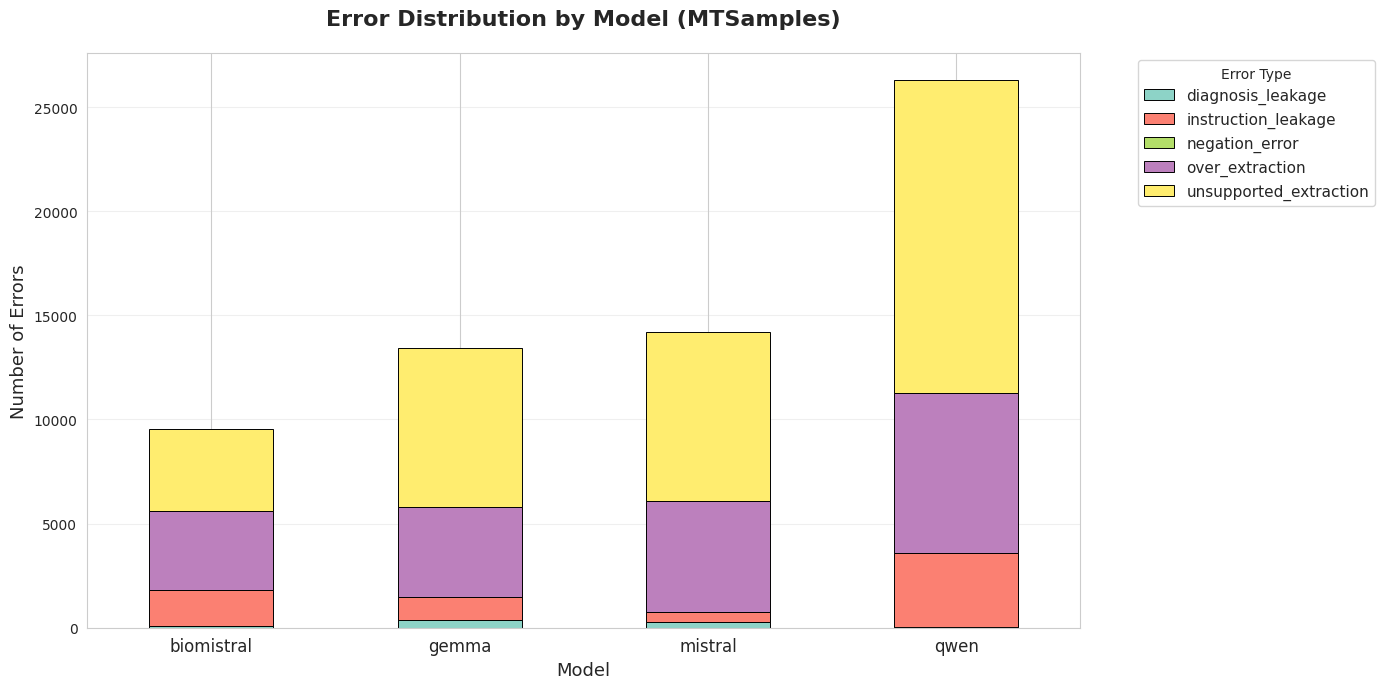

✓ Saved: mtsamples_viz_02_error_rate.png


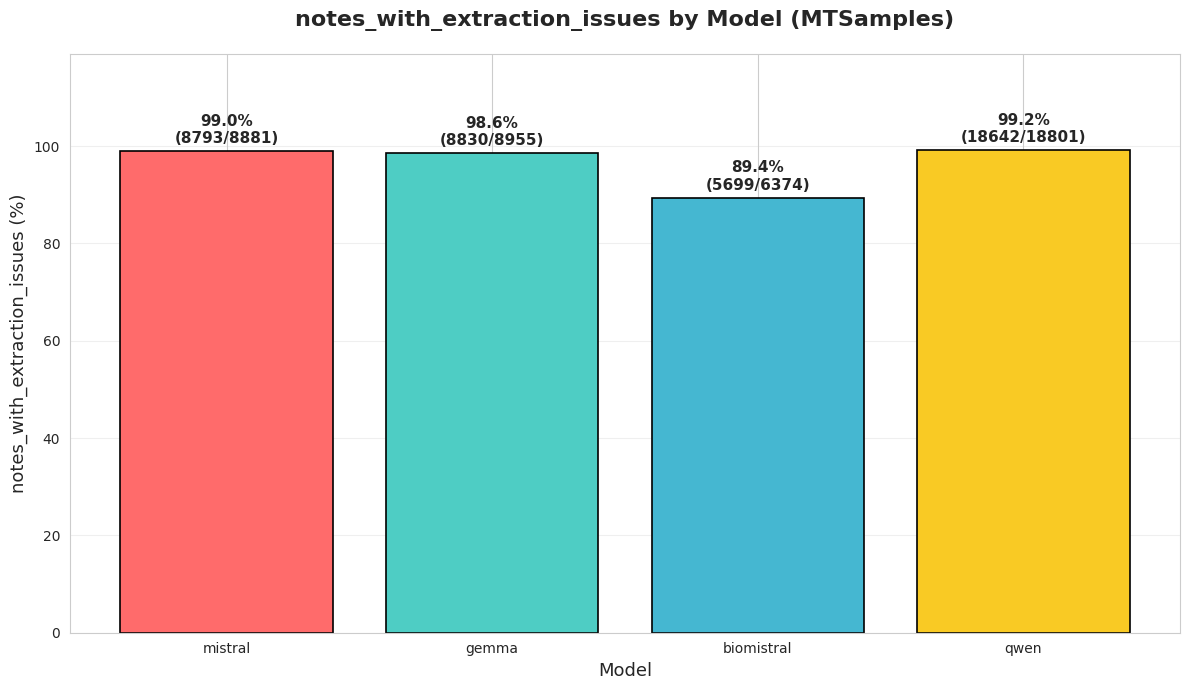

✓ Saved: mtsamples_viz_03_error_heatmap.png


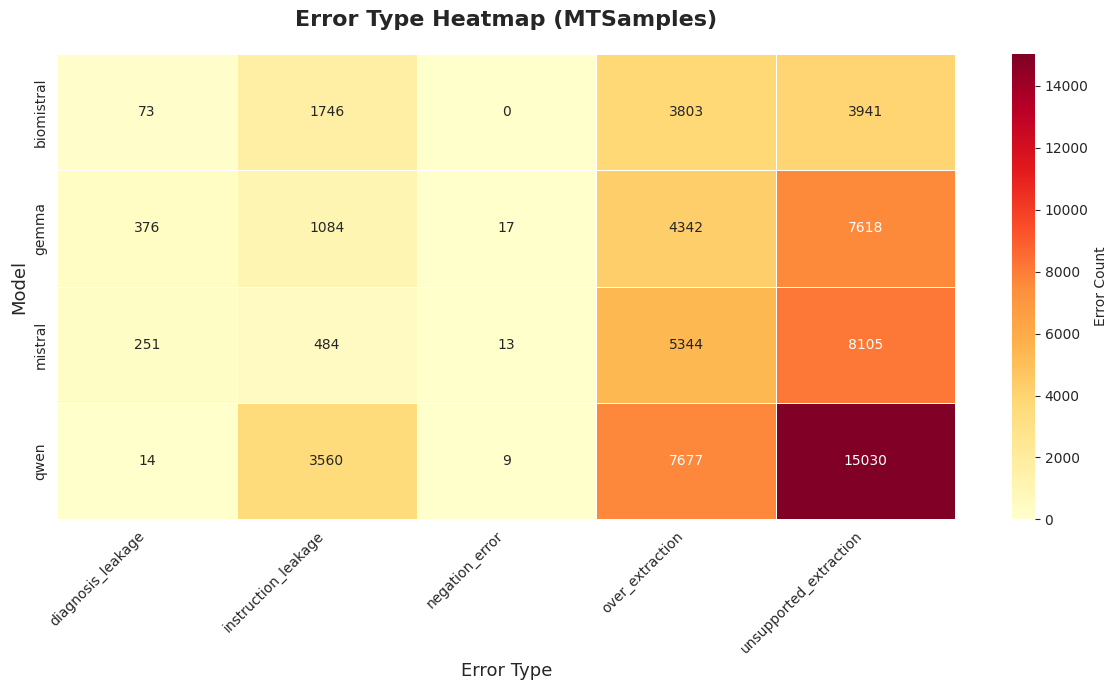

✓ Saved: mtsamples_viz_04_error_pies.png


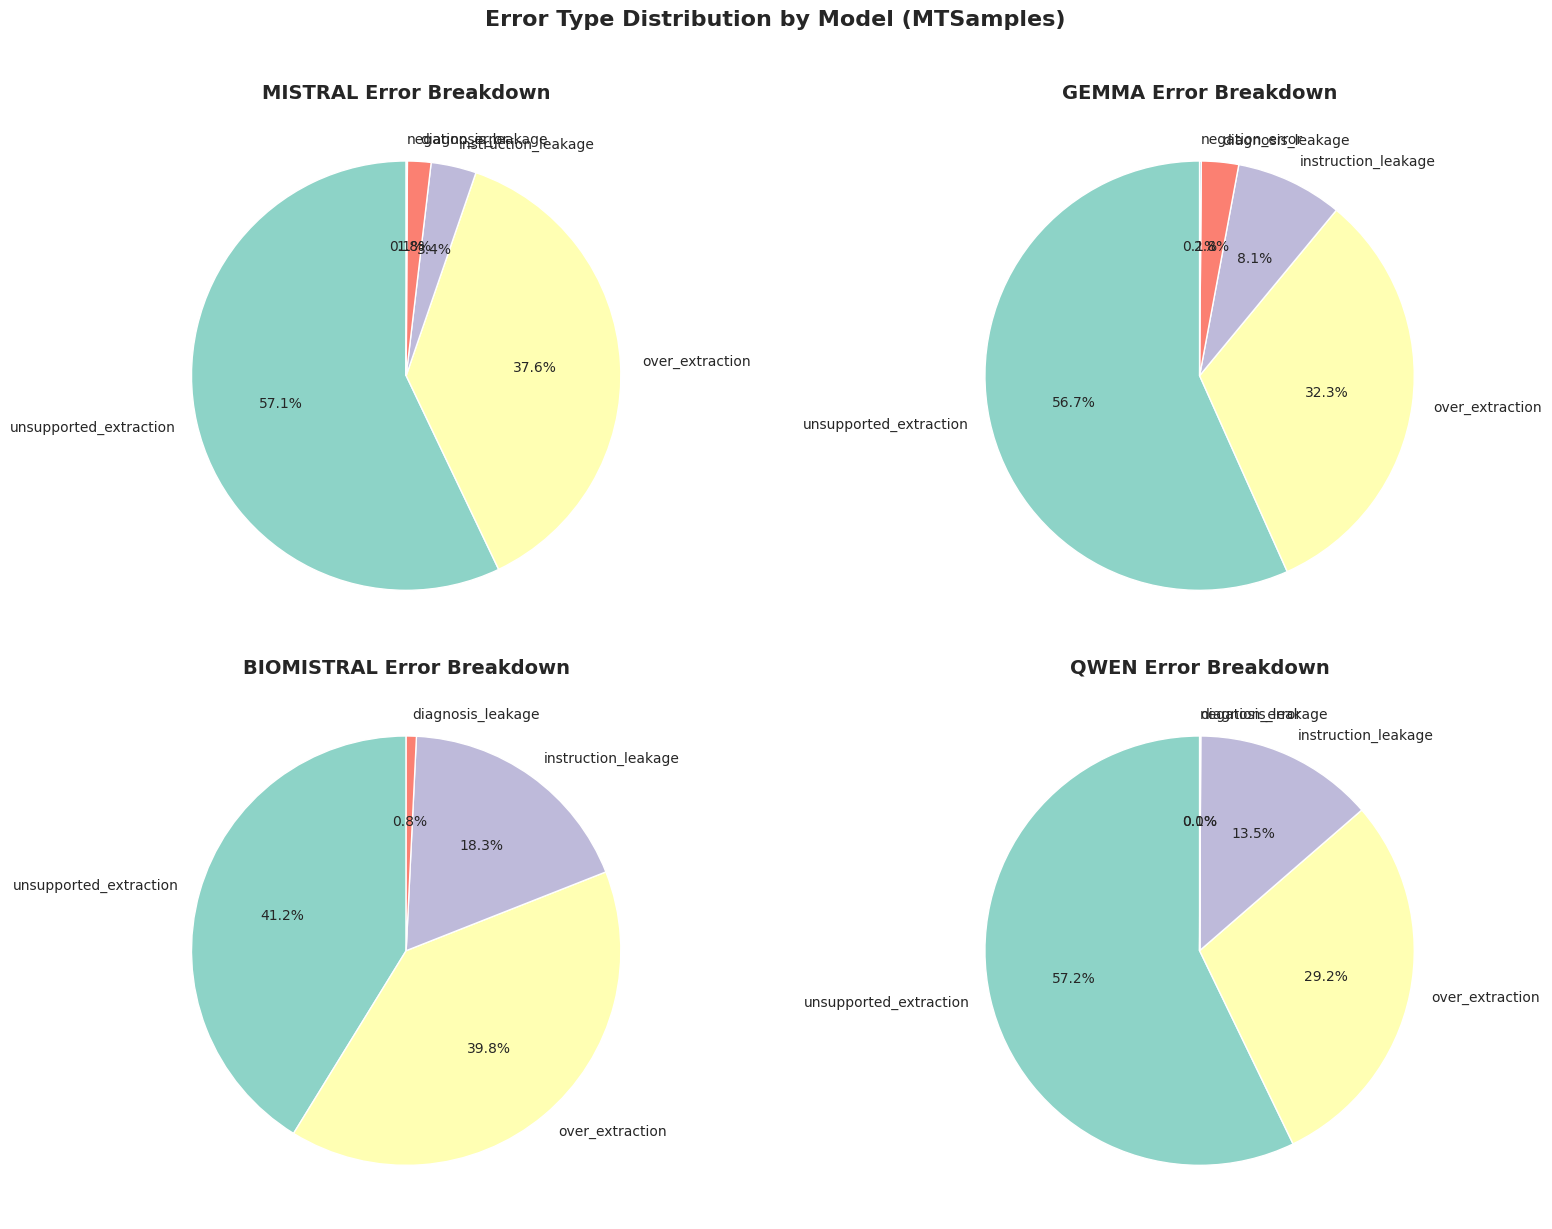

✓ Saved: mtsamples_viz_05_clean_vs_errors.png


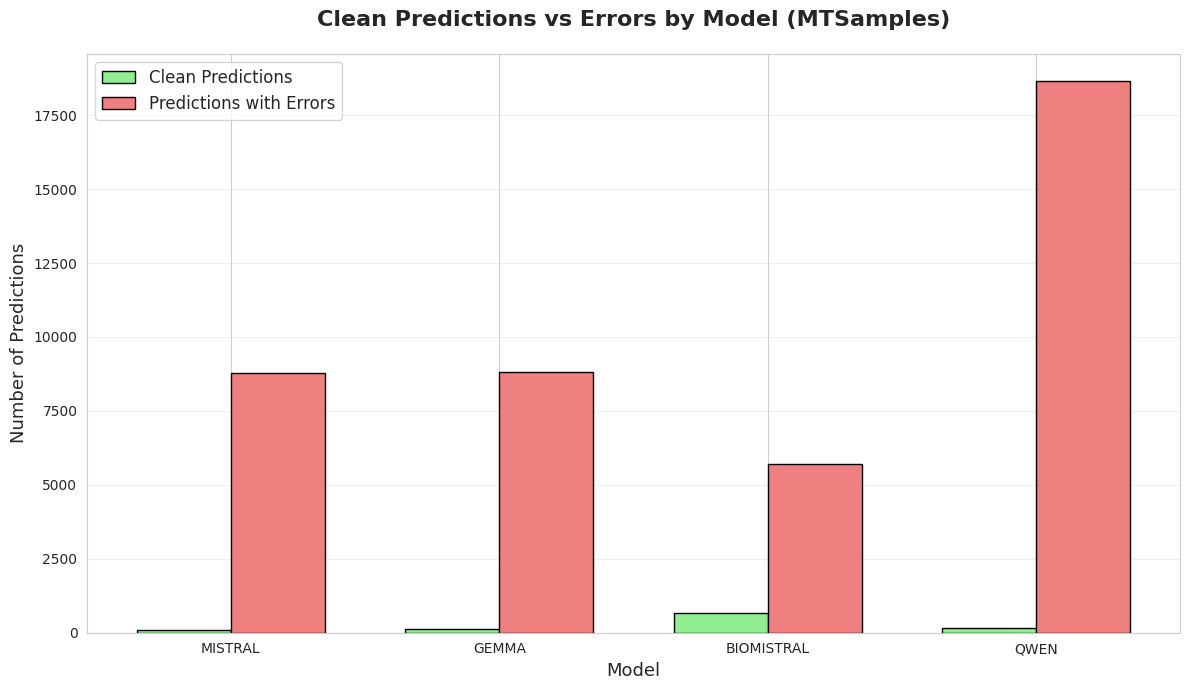


✅ All visualizations created successfully


In [34]:
# CELL 12: Comprehensive Visualizations (CORRECTED)
# ====================================================================

sns.set_style("whitegrid")

print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

# --------------------------------------------------------------------
# VIZ 1: Error Distribution Stacked Bar
# --------------------------------------------------------------------
plt.figure(figsize=(14, 7))
error_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='Set3',
    edgecolor='black',
    linewidth=0.7
)
plt.title('Error Distribution by Model (MTSamples)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Model', fontsize=13)
plt.ylabel('Number of Errors', fontsize=13)
plt.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.xticks(rotation=0, fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mtsamples_viz_01_error_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mtsamples_viz_01_error_distribution.png")
plt.show()

# --------------------------------------------------------------------
# VIZ 2: notes_with_extraction_issues Comparison (FIXED)
# --------------------------------------------------------------------
plt.figure(figsize=(12, 7))

bars = plt.bar(
    stats_df['model'],
    stats_df['error_rate_%'],
    color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24'],
    edgecolor='black',
    linewidth=1.2
)

plt.title('notes_with_extraction_issues by Model (MTSamples)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Model', fontsize=13)
plt.ylabel('notes_with_extraction_issues (%)', fontsize=13)
plt.ylim(0, stats_df['error_rate_%'].max() * 1.2)

# ✅ SAFE annotation using DataFrame indexing
for bar, (_, row) in zip(bars, stats_df.iterrows()):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{row['error_rate_%']:.1f}%\n({row['predictions_with_errors']}/{row['total_predictions']})",
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mtsamples_viz_02_error_rate.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mtsamples_viz_02_error_rate.png")
plt.show()

# --------------------------------------------------------------------
# VIZ 3: Error Type Heatmap
# --------------------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.heatmap(
    error_pivot,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Error Count'},
    linewidths=0.5
)
plt.title('Error Type Heatmap (MTSamples)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Error Type', fontsize=13)
plt.ylabel('Model', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mtsamples_viz_03_error_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mtsamples_viz_03_error_heatmap.png")
plt.show()

# --------------------------------------------------------------------
# VIZ 4: Error Type Distribution (Pie Charts)
# --------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, model in enumerate(models):
    model_errors = errors_df[errors_df['model'] == model]
    error_counts = model_errors['error_type'].value_counts()

    axes[idx].pie(
        error_counts.values,
        labels=error_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('Set3', len(error_counts))
    )
    axes[idx].set_title(f'{model.upper()} Error Breakdown', fontsize=14, fontweight='bold')

plt.suptitle('Error Type Distribution by Model (MTSamples)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mtsamples_viz_04_error_pies.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mtsamples_viz_04_error_pies.png")
plt.show()

# --------------------------------------------------------------------
# VIZ 5: Clean vs Error Predictions
# --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(models))
width = 0.35

clean = stats_df['clean_predictions'].values
errors = stats_df['predictions_with_errors'].values

ax.bar(x - width/2, clean, width, label='Clean Predictions', color='lightgreen', edgecolor='black')
ax.bar(x + width/2, errors, width, label='Predictions with Errors', color='lightcoral', edgecolor='black')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Number of Predictions', fontsize=13)
ax.set_title('Clean Predictions vs Errors by Model (MTSamples)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mtsamples_viz_05_clean_vs_errors.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mtsamples_viz_05_clean_vs_errors.png")
plt.show()

print("\n✅ All visualizations created successfully")

In [35]:
# CELL 13: Select Representative Examples
# ====================================================================

print("\n" + "="*70)
print("SELECTING REPRESENTATIVE EXAMPLES FOR PAPER")
print("="*70)

examples = []
error_types = errors_df['error_type'].unique()

for error_type in error_types:
    subset = errors_df[errors_df["error_type"] == error_type]
    
    if len(subset) > 0:
        # Select diverse examples across models
        selected = []
        
        for model in models:
            model_subset = subset[subset["model"] == model]
            if len(model_subset) > 0:
                sample = model_subset.sample(min(1, len(model_subset)), random_state=42)
                selected.append(sample)
        
        if selected:
            examples.append(pd.concat(selected).head(3))

if examples:
    examples_df = pd.concat(examples).reset_index(drop=True)
    examples_df = examples_df[['model', 'error_type', 'symptom', 'note_excerpt', 'medical_specialty']]
    
    examples_df.to_csv(f"{OUTPUT_DIR}/mtsamples_error_examples_for_paper.csv", index=False)
    print(f"✓ Saved {len(examples_df)} representative examples")
    
    print("\nSample examples:")
    print(examples_df.head(10).to_string(index=False))


SELECTING REPRESENTATIVE EXAMPLES FOR PAPER
✓ Saved 15 representative examples

Sample examples:
     model             error_type                                                                                    symptom                                                                                                                                                                                                                                                                                                 note_excerpt              medical_specialty
   mistral        over_extraction                                                                 good stream, emptying well REASON FOR VISIT:,  Postoperative visit for craniopharyngioma.,HISTORY OF PRESENT ILLNESS:,  Briefly, a 16-year-old right-handed boy who is in eleventh grade, who presents with some blurred vision and visual acuity difficulties, was found to have a suprasellar tumor.  He was brought to the operating  SOAP / Chart / Pro

In [36]:
# CELL X: Cross-Model Jaccard Agreement (MTSamples) — FIXED
# ====================================================================

from itertools import combinations

print("\n" + "="*70)
print("CROSS-MODEL JACCARD AGREEMENT (MTSAMPLES)")
print("="*70)

def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)

# Ensure all models share the same note_ids
common_note_ids = set.intersection(
    *[set(preds[m]["note_id"]) for m in models]
)

common_note_ids = sorted(list(common_note_ids))  # 🔧 FIX

print(f"✓ Common notes across all models: {len(common_note_ids)}")

# Build per-note symptom sets
model_symptom_sets = {}

for model in models:
    df = preds[model].set_index("note_id")
    model_symptom_sets[model] = (
        df.loc[common_note_ids]["predicted_symptoms"]
        .apply(lambda x: set(s for s in x if s != "none"))
    )

# Compute pairwise Jaccard agreement
jaccard_rows = []

for m1, m2 in combinations(models, 2):
    scores = []
    
    for note_id in common_note_ids:
        s1 = model_symptom_sets[m1].loc[note_id]
        s2 = model_symptom_sets[m2].loc[note_id]
        scores.append(jaccard(s1, s2))
    
    jaccard_rows.append({
        "Model 1": m1,
        "Model 2": m2,
        "Mean Jaccard": round(float(np.mean(scores)), 3),
        "Median Jaccard": round(float(np.median(scores)), 3)
    })

jaccard_df = pd.DataFrame(jaccard_rows)

print("\nJaccard Agreement Table:")
print(jaccard_df.to_string(index=False))

# Save
jaccard_df.to_csv(f"{OUTPUT_DIR}/mtsamples_table_jaccard_agreement.csv", index=False)
print(f"\n✓ Saved: mtsamples_table_jaccard_agreement.csv")


CROSS-MODEL JACCARD AGREEMENT (MTSAMPLES)
✓ Common notes across all models: 2000

Jaccard Agreement Table:
   Model 1    Model 2  Mean Jaccard  Median Jaccard
   mistral      gemma         0.063             0.0
   mistral biomistral         0.072             0.0
   mistral       qwen         0.082             0.0
     gemma biomistral         0.105             0.0
     gemma       qwen         0.163             0.0
biomistral       qwen         0.244             0.0

✓ Saved: mtsamples_table_jaccard_agreement.csv


In [37]:
# CELL 14: Summary Statistics
# ====================================================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"\nDIAGNOSIS DETECTION SETUP:")
print(f"  Curated diagnosis terms: {len(CURATED_DIAGNOSES)}")
print(f"  Diagnosis suffix patterns: {len(DIAGNOSIS_SUFFIXES)}")
print(f"  Borderline conditions tracked: {len(BORDERLINE_CONDITIONS)}")

print(f"\nDATA-DRIVEN PATTERN EXTRACTION:")
print(f"  Medication patterns extracted: {len(MEDICATION_PATTERNS)}")
print(f"  Vital sign patterns extracted: {len(VITAL_PATTERNS)}")
print(f"  Lab test patterns extracted: {len(LAB_PATTERNS)}")
print(f"  Instruction leakage patterns extracted: {len(INSTRUCTION_LEAKAGE_PATTERNS)}")

print(f"\nERROR ANALYSIS:")
print(f"  Total errors across all models: {len(errors_df)}")
print(f"  Unique error types: {errors_df['error_type'].nunique()}")

print("\n" + "="*70)
print("✅ MTSamples Qualitative Analysis Complete")
print("="*70)

print("\nFiles Generated:")
files = [
    "extracted_diagnosis_terms.csv",
    "extracted_clinical_patterns.csv",
    "instruction_leakage_patterns.csv",
    "mtsamples_all_errors.csv",
    "mtsamples_prediction_stats.csv",
    "mtsamples_error_distribution.csv",
    "mtsamples_error_examples_for_paper.csv",
    "mtsamples_table_jaccard_agreement.csv"
    "mtsamples_viz_01_error_distribution.png",
    "mtsamples_viz_02_error_rate.png",
    "mtsamples_viz_03_error_heatmap.png",
    "mtsamples_viz_04_error_pies.png",
    "mtsamples_viz_05_clean_vs_errors.png",
]

for f in files:
    print(f"  ✓ {f}")


FINAL SUMMARY

DIAGNOSIS DETECTION SETUP:
  Curated diagnosis terms: 35
  Diagnosis suffix patterns: 10
  Borderline conditions tracked: 13

DATA-DRIVEN PATTERN EXTRACTION:
  Medication patterns extracted: 203
  Vital sign patterns extracted: 37
  Lab test patterns extracted: 40
  Instruction leakage patterns extracted: 63

ERROR ANALYSIS:
  Total errors across all models: 63487
  Unique error types: 5

✅ MTSamples Qualitative Analysis Complete

Files Generated:
  ✓ extracted_diagnosis_terms.csv
  ✓ extracted_clinical_patterns.csv
  ✓ instruction_leakage_patterns.csv
  ✓ mtsamples_all_errors.csv
  ✓ mtsamples_prediction_stats.csv
  ✓ mtsamples_error_distribution.csv
  ✓ mtsamples_error_examples_for_paper.csv
  ✓ mtsamples_table_jaccard_agreement.csvmtsamples_viz_01_error_distribution.png
  ✓ mtsamples_viz_02_error_rate.png
  ✓ mtsamples_viz_03_error_heatmap.png
  ✓ mtsamples_viz_04_error_pies.png
  ✓ mtsamples_viz_05_clean_vs_errors.png


In [38]:
import zipfile
import os

zip_path = "/kaggle/working/mtsamples_results_selected.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk("/kaggle/working"):
        for file in files:
            if file.endswith((".csv", ".png", ".json")):
                full_path = os.path.join(root, file)
                zipf.write(full_path, arcname=file)

print(f"✅ Created ZIP: {zip_path}")

✅ Created ZIP: /kaggle/working/mtsamples_results_selected.zip
